
# IPL 2025 ANALYTICS DASHBOARD

In [2]:
# Import Libraries
# ─────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Load Datasets
# ─────────────────────────────────────────────────────────────
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("📄 matches.csv — Shape:", matches.shape)
print("📄 deliveries.csv — Shape:", deliveries.shape)
print("\n--- First 5 rows of matches ---")
matches.head()

📄 matches.csv — Shape: (1095, 20)
📄 deliveries.csv — Shape: (260920, 17)

--- First 5 rows of matches ---


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
#Data Exploration & Cleaning
# ─────────────────────────────────────────────────────────────
print("=== MATCHES DATASET INFO ===")
matches.info()

print("\n=== STATISTICAL SUMMARY ===")
print(matches.describe())

print("\n=== MISSING VALUES ===")
print(matches.isnull().sum())

# Drop rows where 'winner' is null (e.g., no-result matches)
matches.dropna(subset=['winner'], inplace=True)
print(f"\n✅ Cleaned dataset — {matches.shape[0]} valid matches retained.")

=== MATCHES DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null 

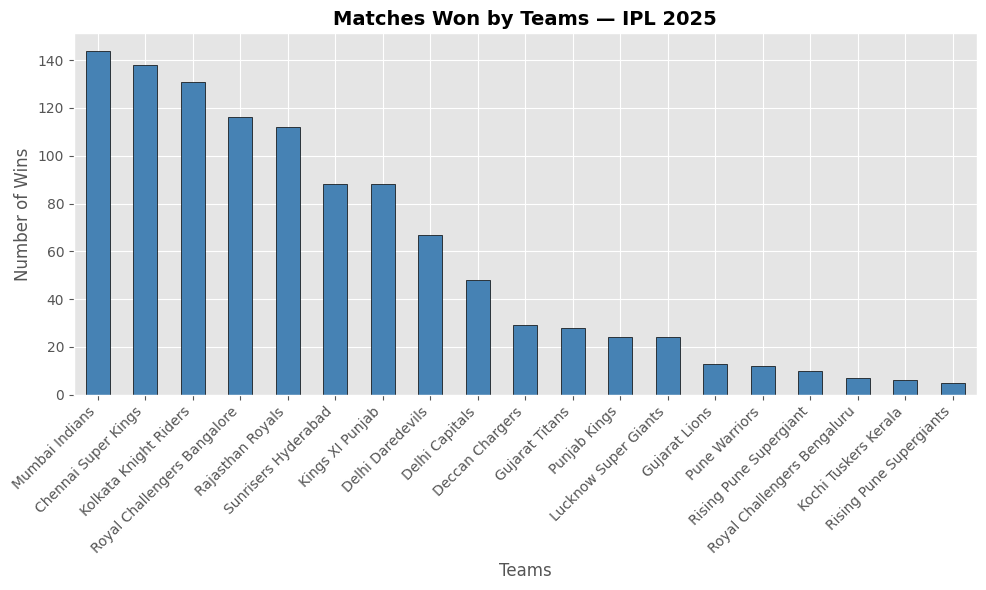

🏆 Most wins: Mumbai Indians — 144 wins


In [7]:
#TASK 1: Matches Won per Team (Bar Chart)
# ─────────────────────────────────────────────────────────────
team_matches = matches['winner'].value_counts()

plt.figure(figsize=(10, 6))
team_matches.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Matches Won by Teams — IPL 2025", fontsize=14, fontweight='bold')
plt.xlabel("Teams", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('task1_wins_bar.png', dpi=150)
plt.show()

print("🏆 Most wins:", team_matches.idxmax(), "—", team_matches.max(), "wins")#

/tmp/ipykernel_9151/2912633120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


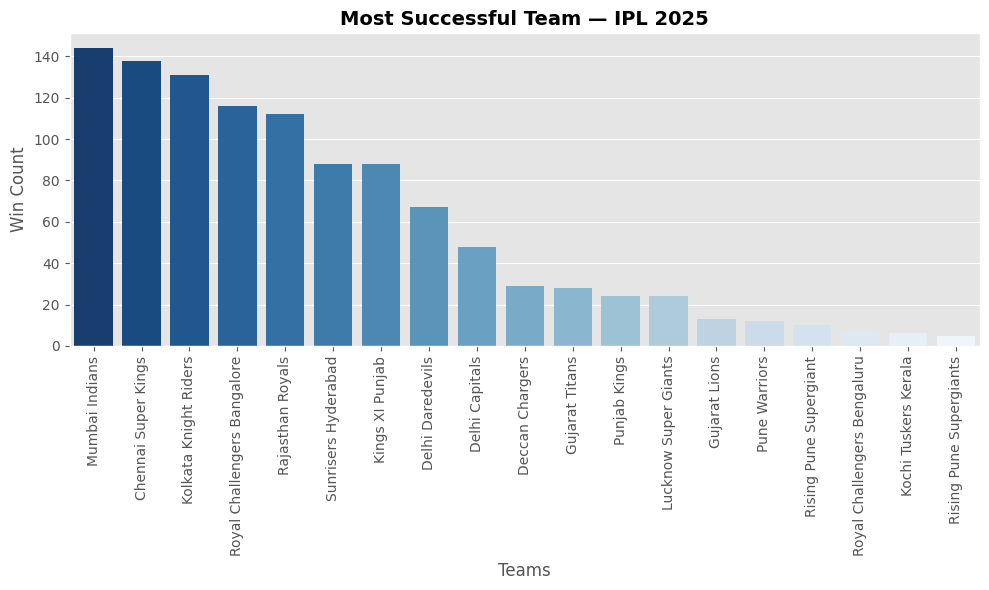

In [8]:
 #TASK 2: Most Successful Team (Seaborn Countplot)
# ─────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
sns.countplot(
    x='winner',
    data=matches,
    order=matches['winner'].value_counts().index,
    palette='Blues_r'
)
plt.xticks(rotation=90)
plt.title("Most Successful Team — IPL 2025", fontsize=14, fontweight='bold')
plt.xlabel("Teams", fontsize=12)
plt.ylabel("Win Count", fontsize=12)
plt.tight_layout()
plt.savefig('task2_most_successful.png', dpi=150)
plt.show()



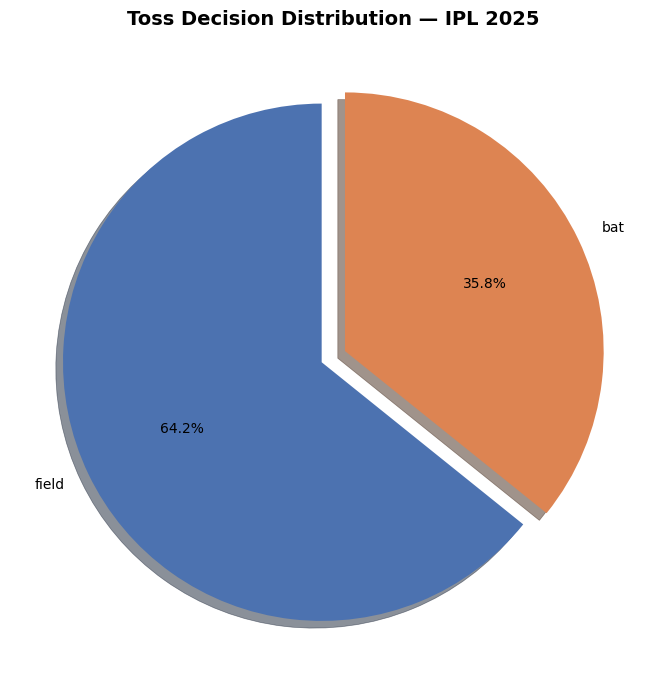

🪙 Toss Decisions:
 toss_decision
field    700
bat      390
Name: count, dtype: int64


In [9]:
#────────────────────────────────────────────────────
# TASK 3: Toss Decision Analysis (Pie Chart)
# ─────────────────────────────────────────────────────────────
toss_counts = matches['toss_decision'].value_counts()

plt.figure(figsize=(7, 7))
toss_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    explode=[0.05, 0.05],
    shadow=True
)
plt.title("Toss Decision Distribution — IPL 2025", fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('task3_toss_pie.png', dpi=150)
plt.show()

print("🪙 Toss Decisions:\n", toss_counts)


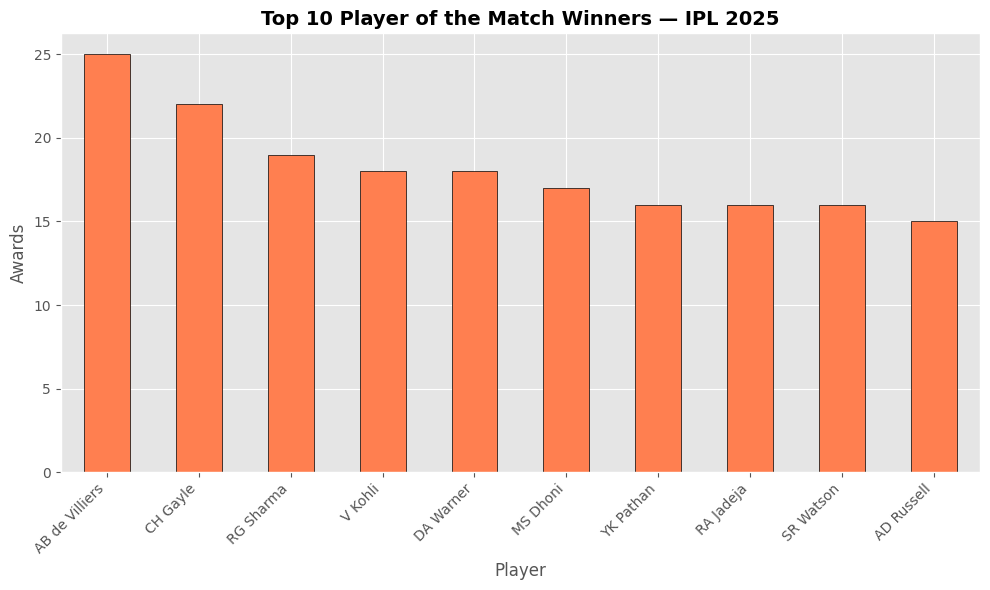

⭐ Top performer: AB de Villiers — 25 awards


In [10]:
#TASK 4: Top 10 Player of the Match Winners
# ─────────────────────────────────────────────────────────────
top_players = matches['player_of_match'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_players.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Top 10 Player of the Match Winners — IPL 2025", fontsize=14, fontweight='bold')
plt.xlabel("Player", fontsize=12)
plt.ylabel("Awards", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('task4_top_players.png', dpi=150)
plt.show()

print("⭐ Top performer:", top_players.idxmax(), "—", top_players.max(), "awards")


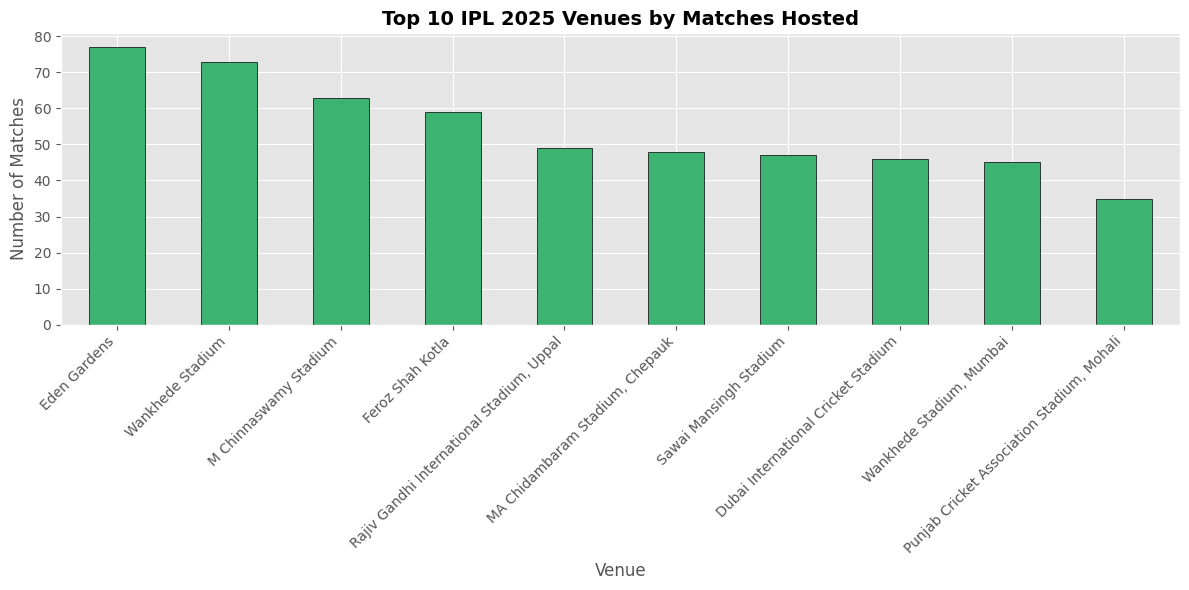

🏟️ Most matches hosted at: Eden Gardens


In [11]:
# TASK 5: Venue Analysis
# ─────────────────────────────────────────────────────────────
venue_matches = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12, 6))
venue_matches.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title("Top 10 IPL 2025 Venues by Matches Hosted", fontsize=14, fontweight='bold')
plt.xlabel("Venue", fontsize=12)
plt.ylabel("Number of Matches", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('task5_venues.png', dpi=150)
plt.show()

print("🏟️ Most matches hosted at:", venue_matches.idxmax())

/tmp/ipykernel_9151/3254450569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


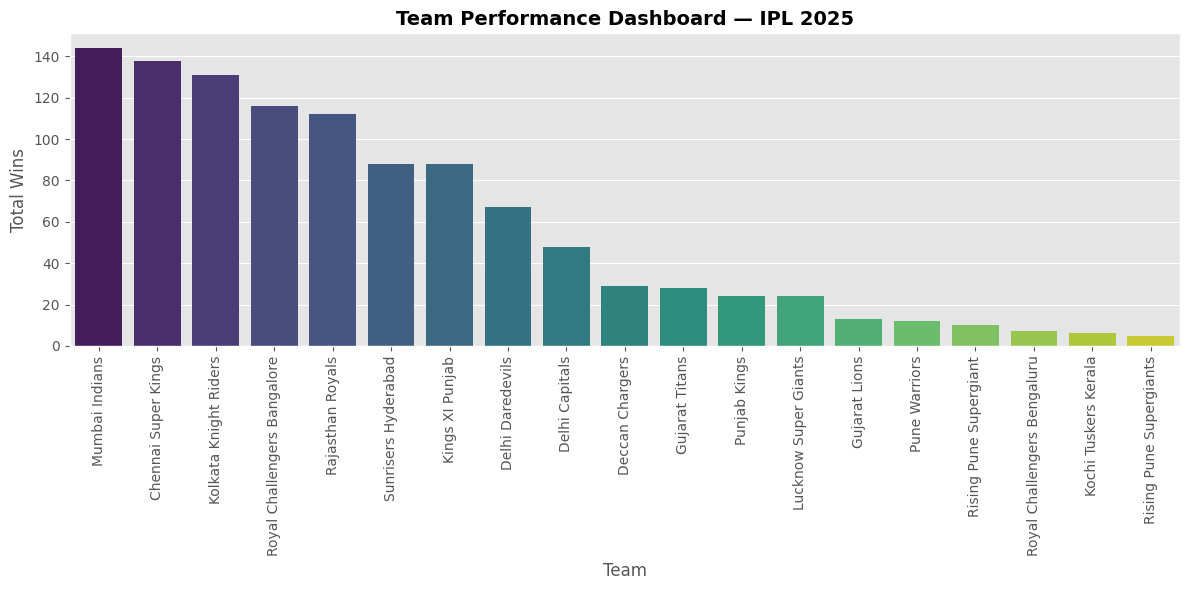

In [12]:
# TASK 6: Team Performance Dashboard (Seaborn)
# ─────────────────────────────────────────────────────────────
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=team_wins.index,
    y=team_wins.values,
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title("Team Performance Dashboard — IPL 2025", fontsize=14, fontweight='bold')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Total Wins", fontsize=12)
plt.tight_layout()
plt.savefig('task6_performance_dashboard.png', dpi=150)
plt.show()


📊 Win Percentages:
 winner
Mumbai Indians                 13.21
Chennai Super Kings            12.66
Kolkata Knight Riders          12.02
Royal Challengers Bangalore    10.64
Rajasthan Royals               10.28
Sunrisers Hyderabad             8.07
Kings XI Punjab                 8.07
Delhi Daredevils                6.15
Delhi Capitals                  4.40
Deccan Chargers                 2.66
Name: count, dtype: float64


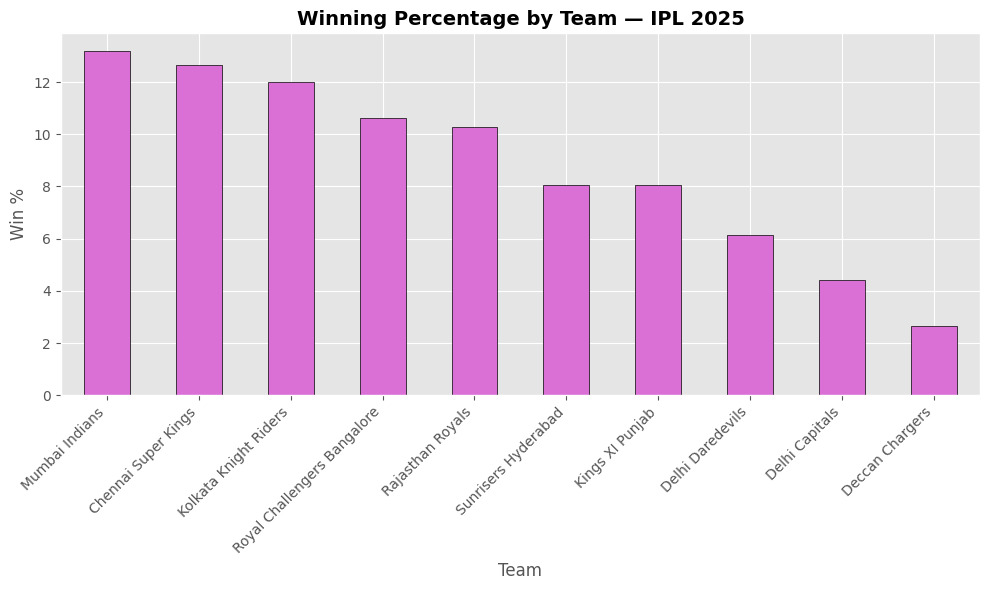

In [13]:
#  TASK 7: Winning Percentage per Team
# ─────────────────────────────────────────────────────────────
total_matches = matches.shape[0]
wins = matches['winner'].value_counts()
win_percentage = (wins / total_matches * 100).round(2)

print("📊 Win Percentages:\n", win_percentage.head(10))

plt.figure(figsize=(10, 6))
win_percentage.head(10).plot(kind='bar', color='orchid', edgecolor='black')
plt.title("Winning Percentage by Team — IPL 2025", fontsize=14, fontweight='bold')
plt.xlabel("Team", fontsize=12)
plt.ylabel("Win %", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('task7_win_percentage.png', dpi=150)
plt.show()

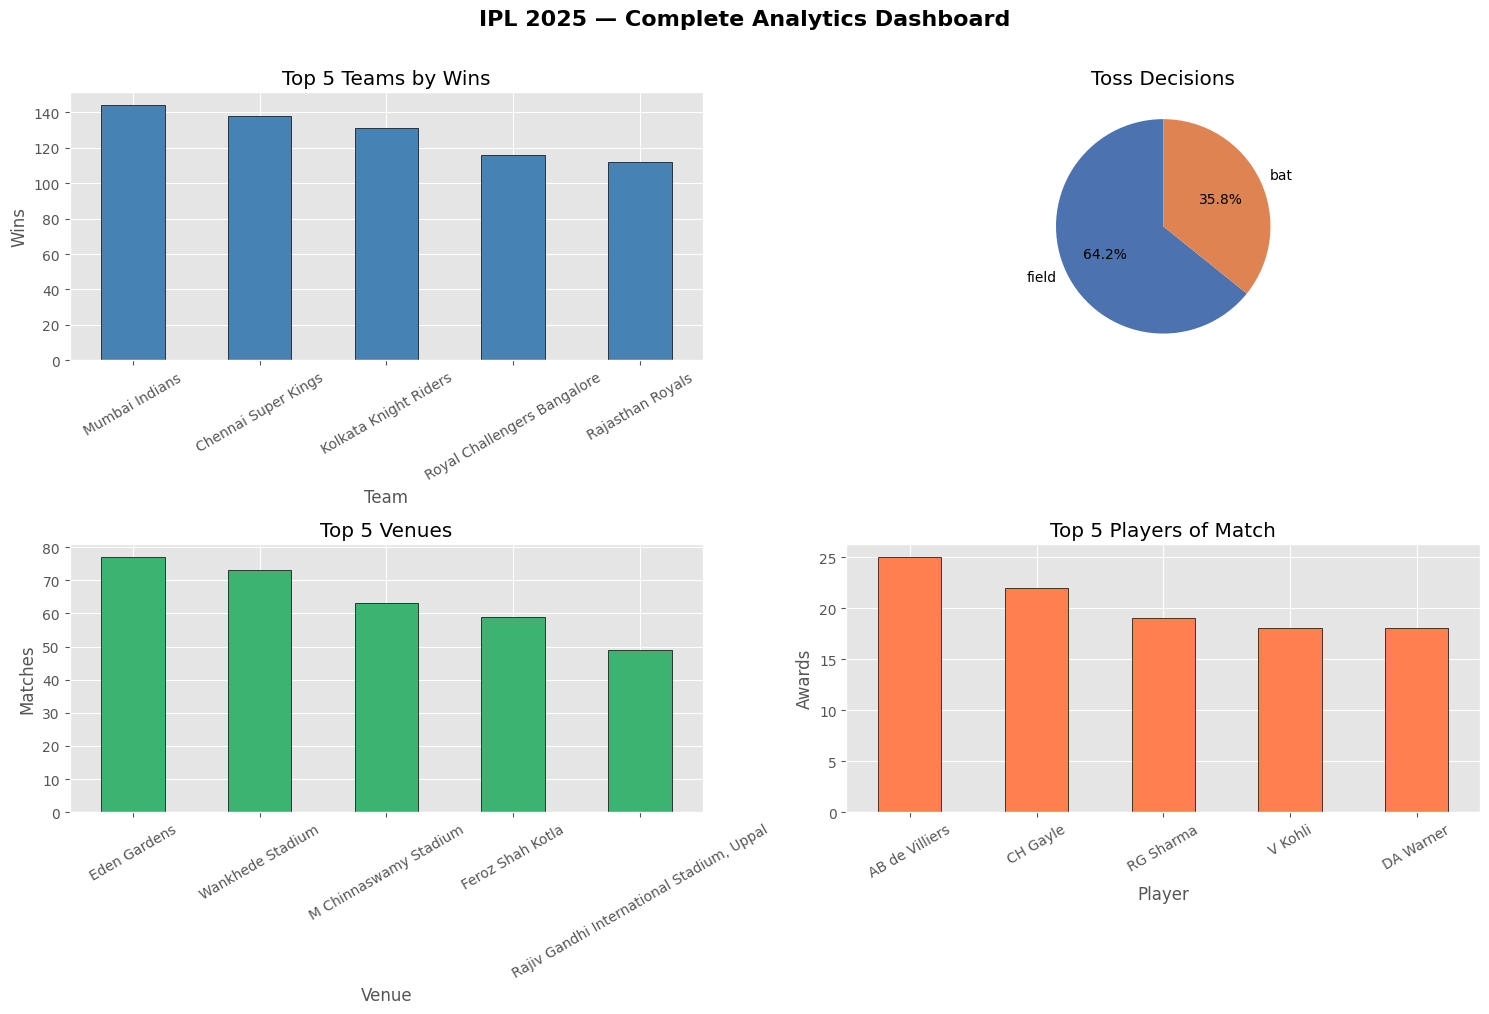

✅ Full dashboard saved as task8_full_dashboard.png

🎯 Model Accuracy: 44.95%

📋 Classification Report:

                             precision    recall  f1-score   support

        Chennai Super Kings       0.63      0.59      0.61        37
            Deccan Chargers       0.00      0.00      0.00         2
             Delhi Capitals       0.29      0.29      0.29         7
           Delhi Daredevils       0.37      0.54      0.44        13
              Gujarat Lions       0.50      0.40      0.44         5
             Gujarat Titans       0.60      0.33      0.43         9
            Kings XI Punjab       0.33      0.12      0.17        17
       Kochi Tuskers Kerala       0.00      0.00      0.00         2
      Kolkata Knight Riders       0.42      0.61      0.50        23
       Lucknow Super Giants       0.25      0.33      0.29         3
             Mumbai Indians       0.50      0.73      0.59        26
              Pune Warriors       0.33      0.33      0.33         

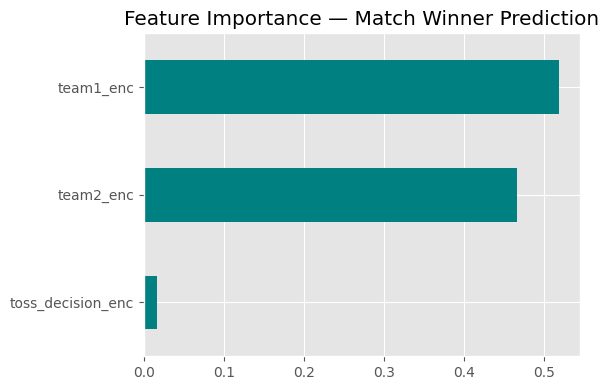


✅ All tasks complete! Screenshots of each chart can be downloaded from Colab's file browser.


In [16]:
# — TASK 8: Full 2×2 Dashboard
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("IPL 2025 — Complete Analytics Dashboard", fontsize=16, fontweight='bold', y=1.01)

# Panel [0,0] — Top 5 Teams by Wins
matches['winner'].value_counts().head(5).plot(
    kind='bar', ax=ax[0, 0], color='steelblue', edgecolor='black'
)
ax[0, 0].set_title("Top 5 Teams by Wins")
ax[0, 0].set_xlabel("Team")
ax[0, 0].set_ylabel("Wins")
ax[0, 0].tick_params(axis='x', rotation=30)

# Panel [0,1] — Toss Decision Pie Chart
matches['toss_decision'].value_counts().plot(
    kind='pie', ax=ax[0, 1], autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'], startangle=90
)
ax[0, 1].set_title("Toss Decisions")
ax[0, 1].set_ylabel('')

# Panel [1,0] — Top 5 Venues
matches['venue'].value_counts().head(5).plot(
    kind='bar', ax=ax[1, 0], color='mediumseagreen', edgecolor='black'
)
ax[1, 0].set_title("Top 5 Venues")
ax[1, 0].set_xlabel("Venue")
ax[1, 0].set_ylabel("Matches")
ax[1, 0].tick_params(axis='x', rotation=30)

# Panel [1,1] — Top 5 Player of Match
matches['player_of_match'].value_counts().head(5).plot(
    kind='bar', ax=ax[1, 1], color='coral', edgecolor='black'
)
ax[1, 1].set_title("Top 5 Players of Match")
ax[1, 1].set_xlabel("Player")
ax[1, 1].set_ylabel("Awards")
ax[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('task8_full_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Full dashboard saved as task8_full_dashboard.png")


# --------- Predict Match Winner with ML----------
# ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Reload clean copy to avoid pollution from previous steps
ml_data = pd.read_csv('matches.csv').dropna(subset=['winner', 'team1', 'team2'])

# Encode categorical columns
le_team = LabelEncoder()
all_teams = pd.concat([ml_data['team1'], ml_data['team2'], ml_data['winner']]).unique()
le_team.fit(all_teams)

ml_data['team1_enc'] = le_team.transform(ml_data['team1'])
ml_data['team2_enc'] = le_team.transform(ml_data['team2'])
ml_data['winner_enc'] = le_team.transform(ml_data['winner'])

# Optionally encode toss_decision and toss_winner for better accuracy
le_toss = LabelEncoder()
ml_data['toss_decision_enc'] = le_toss.fit_transform(ml_data['toss_decision'])

# Features & Target
X = ml_data[['team1_enc', 'team2_enc', 'toss_decision_enc']]
y = ml_data['winner_enc']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\n📋 Classification Report:\n")

# Get the unique classes present in the test set
actual_labels = sorted(y_test.unique())

# Create target names corresponding to these actual labels
# This maps the integer labels back to the team names
actual_target_names = [le_team.classes_[label] for label in actual_labels]

print(classification_report(y_test, y_pred, labels=actual_labels, target_names=actual_target_names, zero_division=0))

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(6, 4))
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance — Match Winner Prediction")
plt.tight_layout()
plt.savefig('bonus_feature_importance.png', dpi=150)
plt.show()

print("\n✅ All tasks complete! Screenshots of each chart can be downloaded from Colab's file browser.")